In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

project_path = "/content/drive/MyDrive/Water_AI_Hackathon"
os.chdir(project_path)

print(os.getcwd())

/content/drive/MyDrive/Water_AI_Hackathon


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv("datasets/scarcity.csv")

In [6]:
country_encoder = LabelEncoder()
df["Country"] = country_encoder.fit_transform(df["Country"])

scarcity_encoder = LabelEncoder()
df["Water Scarcity Level"] = scarcity_encoder.fit_transform(
    df["Water Scarcity Level"]
)

In [7]:
#select features nd target
X = df.drop("Water Scarcity Level", axis=1)

y = df["Water Scarcity Level"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [11]:
predictions = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.96


In [13]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       1.00      1.00      1.00        25
           2       0.94      1.00      0.97        68

    accuracy                           0.96       100
   macro avg       0.98      0.81      0.86       100
weighted avg       0.96      0.96      0.95       100



In [14]:
print(confusion_matrix(y_test, predictions))

[[ 3  0  4]
 [ 0 25  0]
 [ 0  0 68]]


In [15]:
#sort feature by importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                                          Feature  Importance
3           Per Capita Water Use (Liters per Day)    0.807832
0                                         Country    0.032992
2  Total Water Consumption (Billion Cubic Meters)    0.028726
4                      Agricultural Water Use (%)    0.028183
7    Rainfall Impact (Annual Precipitation in mm)    0.026739
5                        Industrial Water Use (%)    0.023298
8                  Groundwater Depletion Rate (%)    0.019990
6                         Household Water Use (%)    0.017528
1                                            Year    0.014711


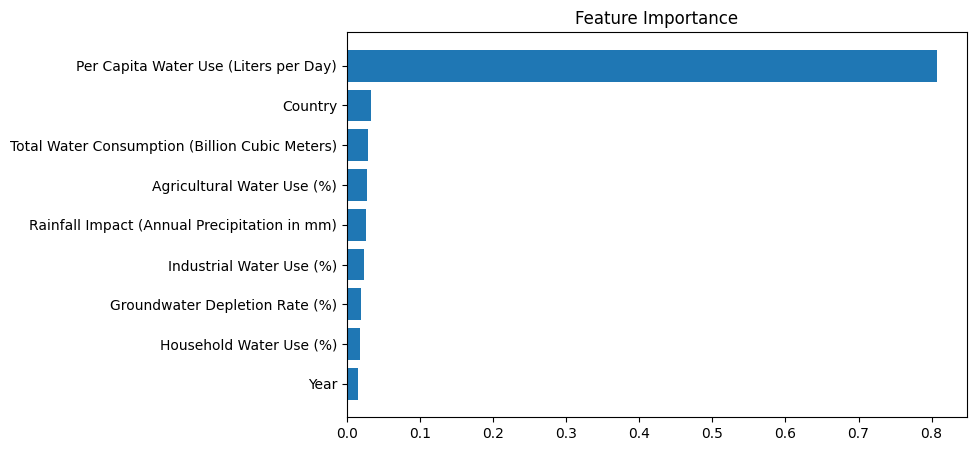

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [17]:
import joblib

joblib.dump(
    model,
    "/content/drive/MyDrive/Water_AI_Hackathon/models/scarcity_model.pkl"
)

['/content/drive/MyDrive/Water_AI_Hackathon/models/scarcity_model.pkl']

In [18]:
joblib.dump(
    scaler,
    "/content/drive/MyDrive/Water_AI_Hackathon/models/scaler.pkl"
)

['/content/drive/MyDrive/Water_AI_Hackathon/models/scaler.pkl']